In [ ]:
##########################################
##### Example of how to analyze TACIT File #####
##########################################
#Created 9/17/2021
#Updated 9/14/2022
#Updated 9/11/2024
#Updated 9/8/2026
#Analyze evolution of predicted open chromatin


In [1]:
##########################################
##### Install the relevant packages #####
##########################################
#This will take several minutes

if (!requireNamespace("BiocManager", quietly = TRUE)) #Install bioconductor, repository of bioinformatics packages in R
    install.packages("BiocManager")

BiocManager::install("edgeR"); #Install the EdgeR package

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'edgeR'

also installing the dependencies ‘statmod’, ‘limma’, ‘locfit’


Old packages: 'bit64', 'curl', 'httr', 'knitr', 'nlme', 'rmarkdown', 'xtable'



In [2]:
install.packages("gplots");


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’




In [3]:
install.packages("ggplot2");

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
install.packages("phylolm");

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘ape’, ‘future.apply’




In [ ]:
#install.packages("geiger"); #Not currently using

In [5]:
##########################################
##### Load the libraries #####
##########################################
library(edgeR);
library(gplots);
library(ggplot2);
library(phylolm);
#library(geiger);


Loading required package: limma


---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess


Loading required package: ape



TACIT - Predicted Open Chromatin Across Mammals

The purpose of this example it to demonstrate how to perform basic analyses of a TACIT dataset, prediction of open chromatin peaks across mammals. These predictions were made by training on example sequences from ATAC-Seq experiments to measure open chromatin in liver and brain. More detailed information about the experiments and procedure can be found here: https://www.science.org/doi/full/10.1126/science.abm7993. In the example matrix provided, all of the peaks shown were originally measured as open chromatin in mouse.

The structure of the data is similar to basic gene expression and epigenetic measures. There is a matrix of predictions (peakPredM), where the peaks across the genome are rows and the species are columns. Every element is the predicted open chromatin value, ranging from 0 (not likely open) to 1 (highly likely open chromatin) in liver.

There is a matrix with information about species (speciesInfoF) that contains various annotations, like evolutionary distance to mouse. This is akin to the sample matrix from the previous lecture on R. There is also a matrix annotating the coordindates of each peak (peakInfoF).

The TACIT framework for comparative evolution can be found here:
https://www.science.org/doi/full/10.1126/science.abm7993


In [6]:
##########################################
##### Read in the relevant datasets #####
##########################################

##### Download the matrix of predicted peaks #####

peakUrl <- "http://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/liver.peakPred.1.csv";
system(paste("wget ",peakUrl));



In [7]:
##### Read the matrix of predicted peaks #####
peakPredM <- as.matrix(read.csv(file="liver.peakPred.1.csv",stringsAsFactors=F,header=T));
peakPredM[1:5,1:5]; #Print out the first 5 rows and columans to make sure things look good.
dim(peakPredM); #Print out the dimensions of the matrix.

specOrderV <- colnames(peakPredM); #For the analysis, it is important that the order and set of species matches.

,Mus_musculus,Acinonyx_jubatus,Acomys_cahirinus,Ailuropoda_melanoleuca,Ailurus_fulgens
peak1_mo,0.8069345,0.1274735,0.1032210,0.1247985,0.0534430
peak3_mo,0.9490730,NA,0.4540265,NA,NA
peak4_mo,0.1770950,NA,0.2692925,NA,NA
peak6_mo,0.7791350,0.4915530,0.7747925,0.6667925,0.6300190
peak9_mo,0.1603685,0.0428695,0.0404525,0.0934600,0.0423175


[1] 12779   222

In [8]:
##### Read in information about each of the peaks #####

featureUrl <- "http://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/liver.peaks.hg38.bed";
peakInfoF <- read.delim(file=featureUrl,stringsAsFactors=F,header=F);
colnames(peakInfoF) <- c("chr","start","stop","id"); #Set the column names for the dataframe of the BED file
rownames(peakInfoF) <- peakInfoF$id; #Set the rownames equal to the peak ID
peakInfoF[1:5,];

dim(peakInfoF);

,chr,start,stop,id
,<chr>,<int>,<int>,<chr>
peak1_mo,chr8,55409100,55409738,peak1_mo
peak3_mo,chr8,55361061,55362189,peak3_mo
peak4_mo,chr8,55361061,55362189,peak4_mo
peak6_mo,chr8,55313270,55313627,peak6_mo
peak9_mo,chr8,55272203,55273932,peak9_mo


[1] 12779     4

In [9]:
##### Read in information about each of the species #####
speciesUrl <- "http://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/ZoonomiaGenomeInfo_3.csv";
speciesInfoF <- read.csv(file=speciesUrl,stringsAsFactors=F,header=T);
rownames(speciesInfoF) <- speciesInfoF$Species
speciesInfoF <- speciesInfoF[specOrderV,]; #Re-order the species to match the prediction matrix
speciesInfoF[1:5,]


,ZoonomiaIndex,Species,CommonName,Clade,MouseSplit_Cactus,MouseSplit_MYA,HumanSplit_MYA,CN50_kb,Scaffold.N50,Scaffold.L50,Contig.N50,Contig.L50,Assembly
,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
Mus_musculus,75,Mus_musculus,House Mouse,Glires,0.00000,0.0,89,32273079,54517951,17,32813180,25,GCF_000001635.26
Acinonyx_jubatus,1,Acinonyx_jubatus,Cheetah,Laurasiatheria,0.77159,96.0,94,35120,3122036,232,35120,19059,GCF_001443585.1
Acomys_cahirinus,122,Acomys_cahirinus,Cairo Spiny Mouse,Glires,0.12066,28.6,89,44337,65411,10134,42476,15859,DISCOVAR (GCA_004027535.1)
Ailuropoda_melanoleuca,2,Ailuropoda_melanoleuca,Giant Panda,Laurasiatheria,0.81346,96.0,94,128604,9947519,75,128604,5279,GCA_002007445.1
Ailurus_fulgens,3,Ailurus_fulgens,Red Panda,Laurasiatheria,0.78542,96.0,94,99577,9947519,75,99577,6772,GCA_002007465.1


In [ ]:
##########################################
##### Study how different types of evolutionary distances from mouse are associated #####
##########################################

This part of the code studies the relationshp between evolutionary distance and evolutionary decay. Evolutionary distance is broadly the distance between two species, but there are different ways to measure that. One method is to use chronological distance in million years ago (MYA) that is based in part of fossil records. Another method is to compute a distance based on genetic differences, including one provided using the cactus multiple sequence alignment tool.

In this section, we will also examine distance based on evolutionary decay. As evolutionary distance increases, the likelihood that the particular region of open chromatin is measured or predicted to be active decreases. This "decay" can be seen in lower predicted open chromatin as we move further from mouse.


	Pearson's product-moment correlation

data:  speciesInfoF[, "MouseSplit_MYA"] and speciesInfoF[, "MouseSplit_Cactus"]
t = 29.151, df = 220, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8605862 0.9154989
sample estimates:
      cor 
0.8912647 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


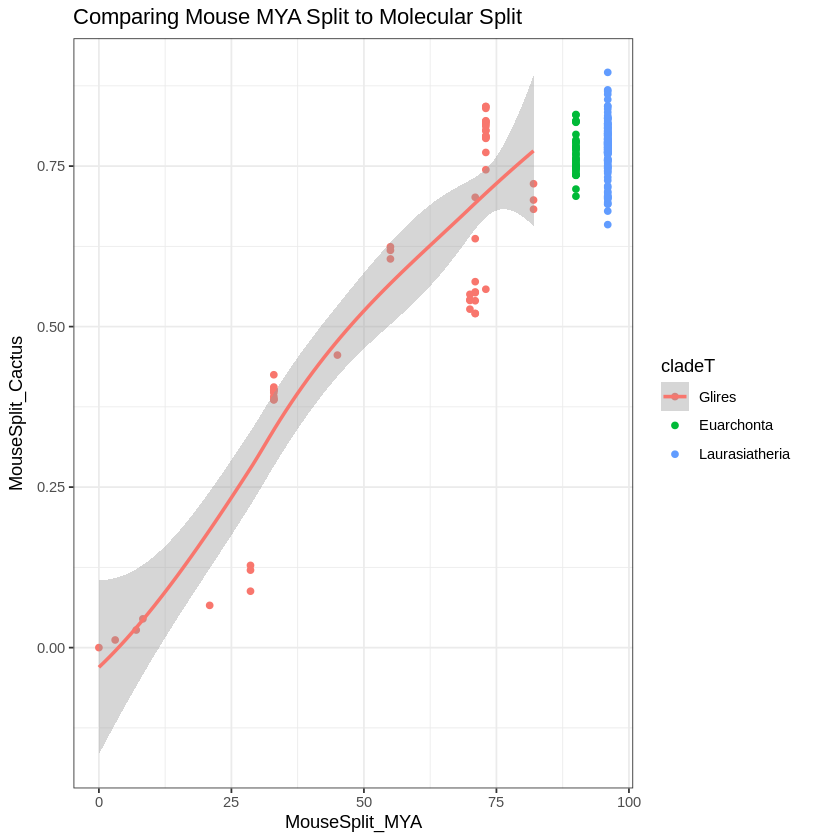

In [10]:
####### How is molecular distance associated with chronological distance? ########

## Use the cor.test function to find the correlation between the CACTUS-based and the chronological time (MYA-based) evolutionary distances.
cor.test(speciesInfoF[,"MouseSplit_MYA"],speciesInfoF[,"MouseSplit_Cactus"] );

## Create a scatter plot comparing the two different types of distances ##
speciesPlotF <- speciesInfoF; #Create a new dataframe, just for the purposes of plotting
#Turn clade into a factor, allowing us to plot them.
speciesPlotF$cladeT <- factor(speciesPlotF$Clade,levels=c("Glires","Euarchonta","Laurasiatheria"));

#Use ggplot to create a scatter plot
curP <- ggplot(speciesPlotF, aes(x = MouseSplit_MYA , y = MouseSplit_Cactus, color=cladeT)) + #Set the data variables to use
  geom_point() + #This specifies that you would like a scatter plot
  geom_smooth(span=.75) + #This creates a trend line
  ggtitle("Comparing Mouse MYA Split to Molecular Split") + #This creates a title for the plot
  theme_bw(); #This sets a basic theme for the plot style

print(curP); #Print the plot



	Pearson's product-moment correlation

data:  speciesInfoF[, "MouseSplit_Cactus"] and peakMeansV
t = -24.181, df = 220, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.8847799 -0.8118653
sample estimates:
       cor 
-0.8524146 


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


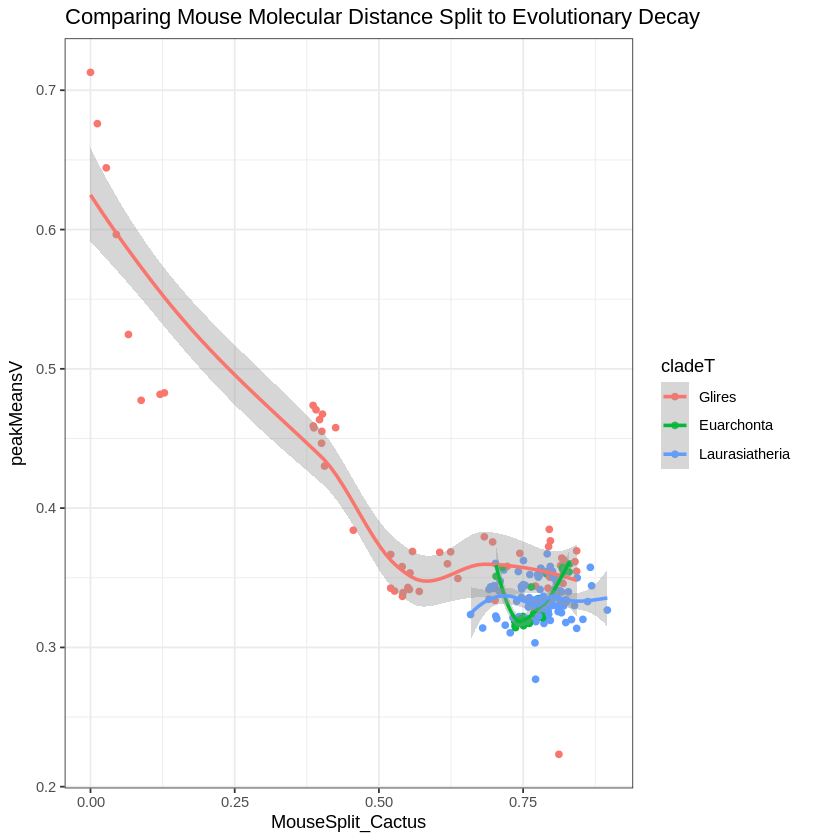

In [11]:
####### How is evolutionary decay related to MYA ########

peakMeansV <- colMeans(peakPredM,na.rm=T); #Compare the mean peak level across each species.


## Create a corrleation ##
cor.test(speciesInfoF[,"MouseSplit_Cactus"],peakMeansV);

## Create a scatter plot ##
speciesPlotF <- speciesInfoF;
speciesPlotF$cladeT <- factor(speciesPlotF$Clade,levels=c("Glires","Euarchonta","Laurasiatheria"));
speciesPlotF$peakMean <- peakMeansV;

curP <- ggplot(speciesPlotF, aes(x = MouseSplit_Cactus , y = peakMeansV, color=cladeT)) +
  geom_point() +
  geom_smooth(span=.75) +
  ggtitle("Comparing Mouse Molecular Distance Split to Evolutionary Decay") +
  theme_bw();

print(curP);


In [ ]:
##########################################
##### Compare datasources for building an evolutionary tree #####
##########################################

This section will cover the basics of how to create an evolutionary tree from different data sources. That includes a set of pair-wise evolutionary distances at the molecular level across genes.

In [12]:
####### Read in the distance matrix based on the whole genome sequence alignment ############
#Low values mean the species are more similar to each other
molecularSimM <- as.matrix(read.csv(file="http://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/200Mammal_hal_tree_noancestors_matrix.csv",stringsAsFactors=F,header=T,row.names=1));

#molecularDistM <- 1 - molecularSimM;
molecularDistM <- molecularSimM
for(curSpec1 in rownames(molecularDistM)) {
  for(curSpec2 in colnames(molecularDistM)) {
    if(curSpec1 != curSpec2) {
      if(is.na(molecularDistM[curSpec1,curSpec2])) {
        molecularDistM[curSpec1,curSpec2] = molecularDistM[curSpec2,curSpec1]
      }
    } else {
      molecularDistM[curSpec1,curSpec2] = 0;
    }
  }
}
#molecularDistM[1:5,1:5]

molecularDistM <- molecularDistM[specOrderV,specOrderV]
molecularDistM[specOrderV[1:5],specOrderV[1:5]]

,Mus_musculus,Acinonyx_jubatus,Acomys_cahirinus,Ailuropoda_melanoleuca,Ailurus_fulgens
Mus_musculus,0.00000,0.77159,0.12066,0.81346,0.78542
Acinonyx_jubatus,0.77159,0.00000,0.77655,0.16105,0.13301
Acomys_cahirinus,0.12066,0.77655,0.00000,0.81842,0.79038
Ailuropoda_melanoleuca,0.81346,0.16105,0.81842,0.00000,0.13488
Ailurus_fulgens,0.78542,0.13301,0.79038,0.13488,0.00000


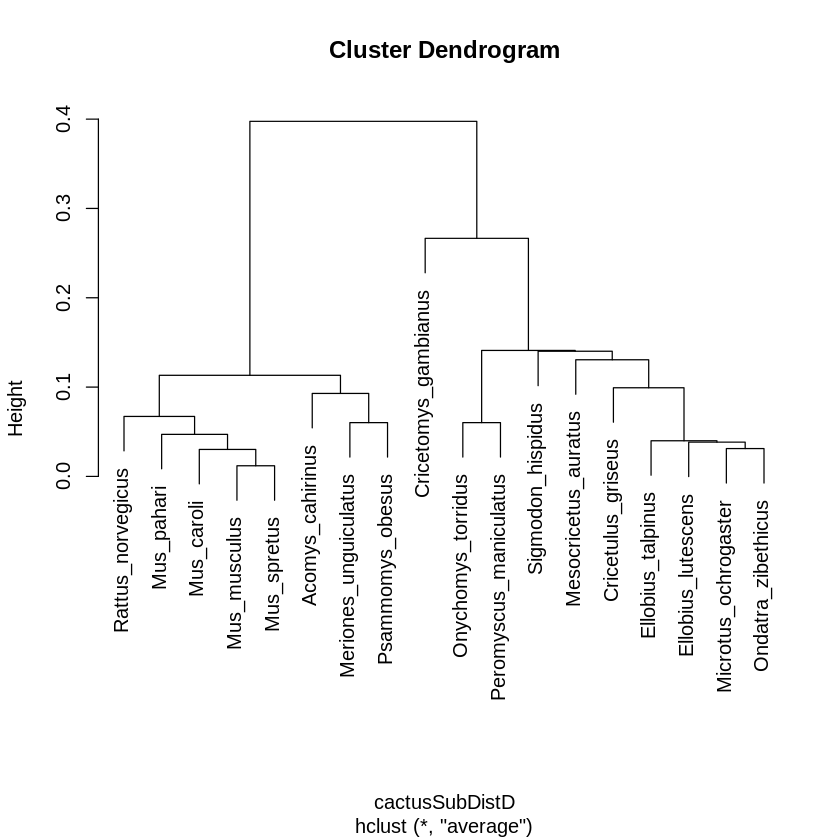

In [13]:
### Hierarchicall cluster a subset of species closely related to mouse ####
myaThresh <- 33; #Set a threshold for million years from mouse
keepSpeciesV <- speciesInfoF[which(speciesInfoF$MouseSplit_MYA <= myaThresh),"Species"]; #Use that threshold to select a group of species
molecularDistSubM <- molecularDistM[keepSpeciesV,keepSpeciesV]; #Subset the molecular distance matrix to only those species

cactusSubDistD <- as.dist(molecularDistSubM); #Create an object of type "distance matrix"
cactusSubCl <- hclust(cactusSubDistD,method="average"); #Cluster based on those distances using average linkage hierarchial clustering
plot(cactusSubCl); #Plot the resulting hierarhcy.


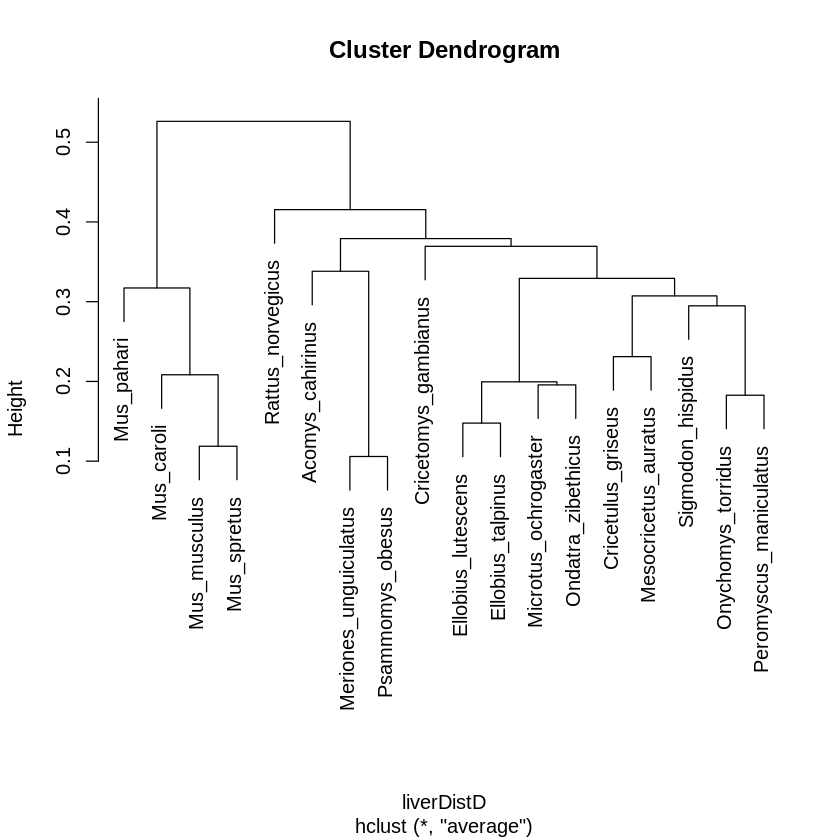

In [14]:
############ Build an evolutionary tree using predicted open chromatin ##############

#Create a matrix of distances based on predicted open chromatin
#This distance used is 1-correlation. The higher correlation, the lower the distance
liverDistM <- 1-cor(peakPredM[,keepSpeciesV],use='pairwise.complete.obs')

#Turn the matrix of distances into a "distance" object
liverDistD <- as.dist(liverDistM);

#Hierarchically cluster the species
liverCl <- hclust(liverDistD,method="average");

#Plot the results of hierarchically clustering
plot(liverCl)

In [ ]:
##########################################
##### Plot traits on a phylogeny #####
##########################################

This section describes how th plot a trait based on a phylogenetic tree. We will read in the mammalian tree and then annotate species across it. This section is particuarly helpful for the project!

In [15]:
### Install the "APE" package which is helpful for visualizing and analyzing phylogenetic trees ###
install.packages('ape')
library(ape) #load ape
#Good examples found here in APE section:
#https://cran.r-project.org/web/packages/ape/ape.pdf
#http://www.sthda.com/english/wiki/beautiful-dendrogram-visualizations-in-r-5-must-known-methods-unsupervised-machine-learning

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [16]:
#Load the mammalian consensus tree. It is in "newick" format, which APE can read.
treeUrl <- "http://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/Zoonomia_ChrX_lessGC40_241species_30Consensus.tree";
system(paste("wget ",treeUrl));
zoonomiaTree <- read.tree(file = "Zoonomia_ChrX_lessGC40_241species_30Consensus.tree") #read tree in Newick format
zoonomiaTree


Phylogenetic tree with 241 tips and 240 internal nodes.

Tip labels:
  Trichechus_manatus, Loxodonta_africana, Heterohyrax_brucei, Procavia_capensis, Chrysochloris_asiatica, Microgale_talazaci, ...

Rooted; includes branch length(s).

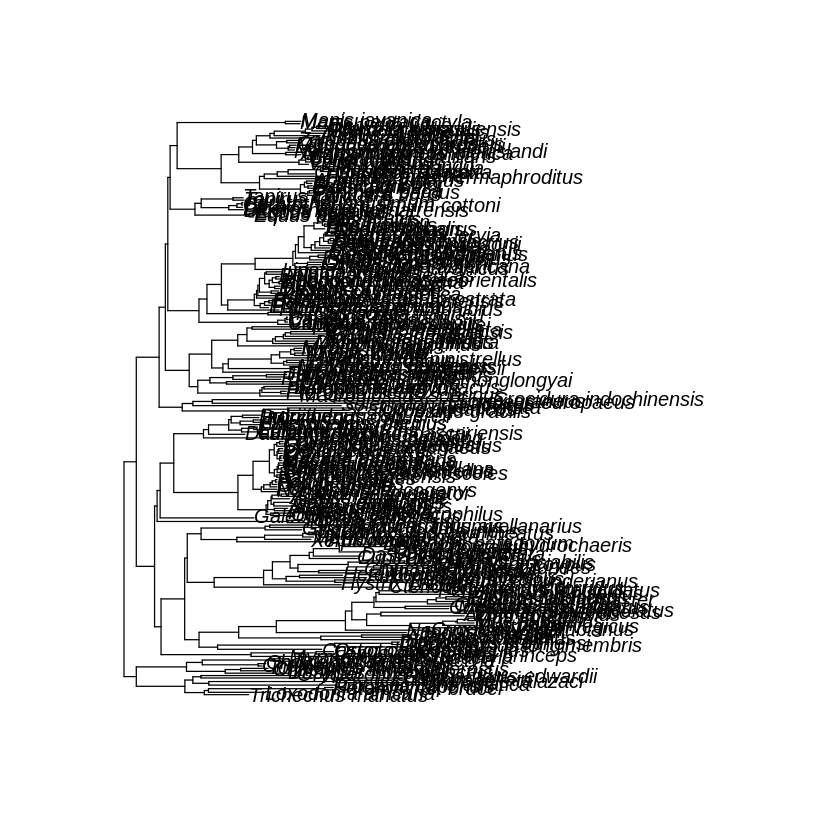

In [17]:
#Use the "plot" function to plot the whole mammalian tree. Major options are included
plot(zoonomiaTree, type = "phylogram", show.tip.label = TRUE,
     edge.color = "black", edge.width = 1, edge.lty = 1,
     tip.color = "black")

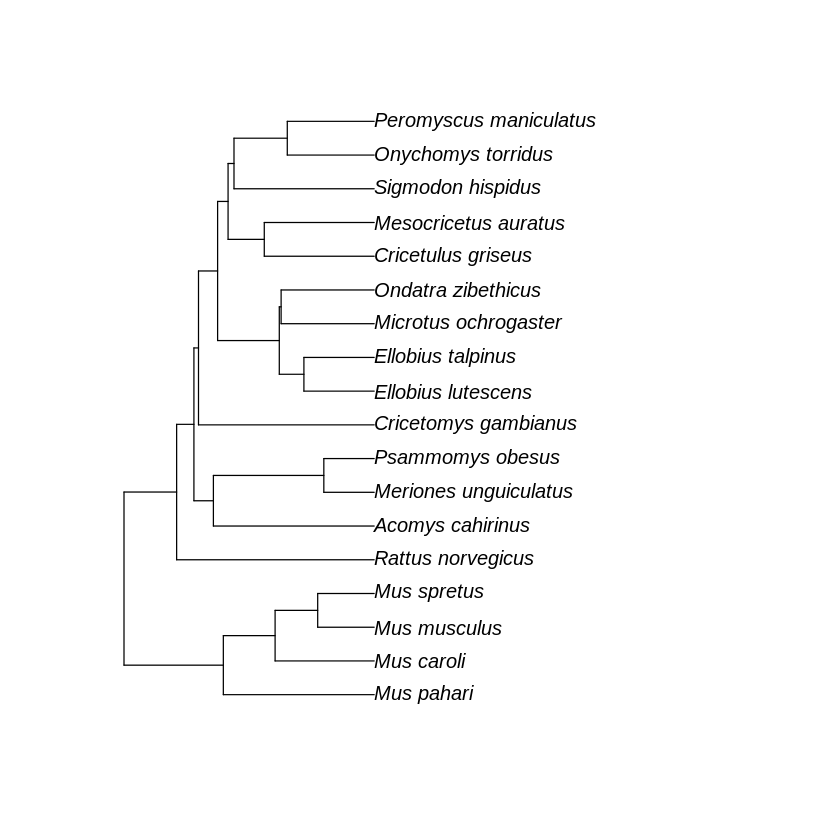

In [18]:
#It is possible to convert cluster objects, like the one we computed for the mouse liver, into phylogenetic tree for APE
#The as.phylo function can perform that task
plot(as.phylo(liverCl), type = "phylogram", show.tip.label = TRUE,
     edge.color = "black", edge.width = 1, edge.lty = 1,
     tip.color = "black")

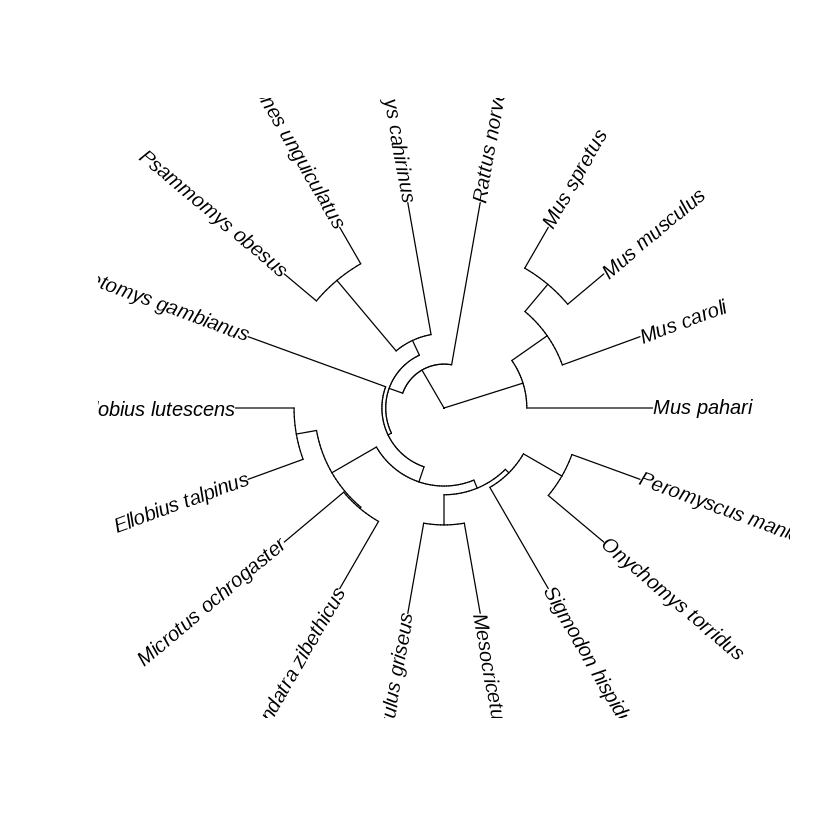

In [19]:
#There are different types of visualization available
plot(as.phylo(liverCl), type = "fan", show.tip.label = TRUE,
     edge.color = "black", edge.width = 1, edge.lty = 1,
     tip.color = "black")

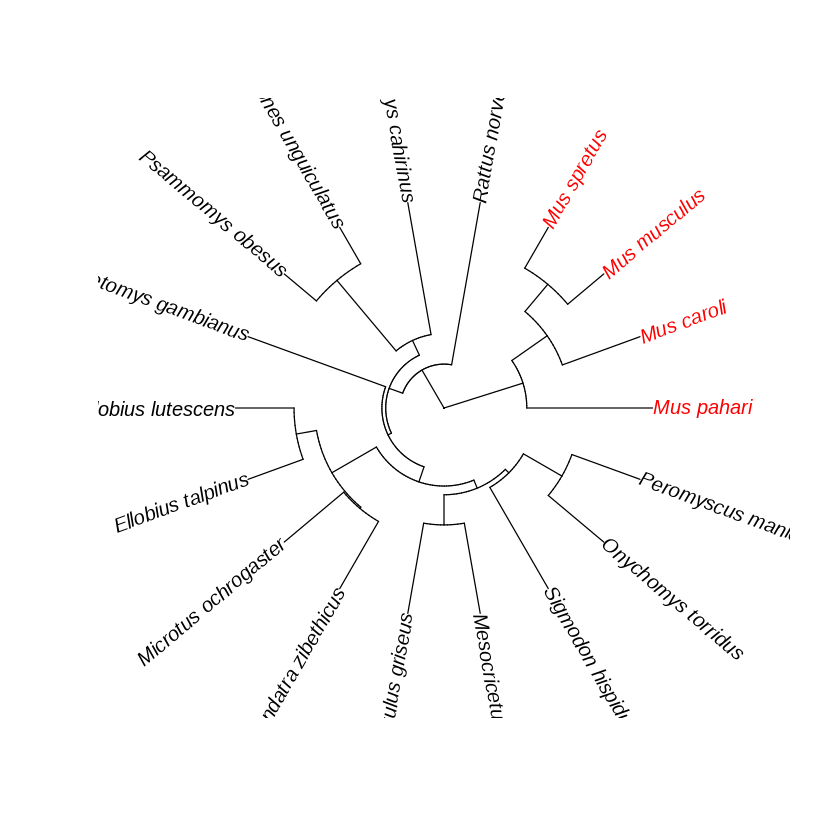

In [20]:
#### Add tip label depending on whether species is mus ######

# Update the speciesInfo dataframe to contain a binary category for being in the mus genus
speciesInfoF$isMus <- "no";
speciesInfoF[which(speciesInfoF$MouseSplit_MYA <= 10),"isMus"] <- "yes";
speciesInfoF$isMusT <- factor(speciesInfoF$isMus,levels=c("no","yes"));

# Apply different colors depending on the whether the animal is in the mus genus
useTipColorsV <- c("black","red"); #Set the differnet colors to use
liverClTree <- as.phylo(liverCl); #Convert the clustering to a tree
tipColorsV <- useTipColorsV[speciesInfoF[liverClTree$tip.label,"isMusT"]]; #Convert the species labels into colors

#Plot the tree with the colors added
plot(liverClTree, type = "fan", show.tip.label = TRUE,
     edge.color = "black", edge.width = 1, edge.lty = 1,
     tip.color = tipColorsV)

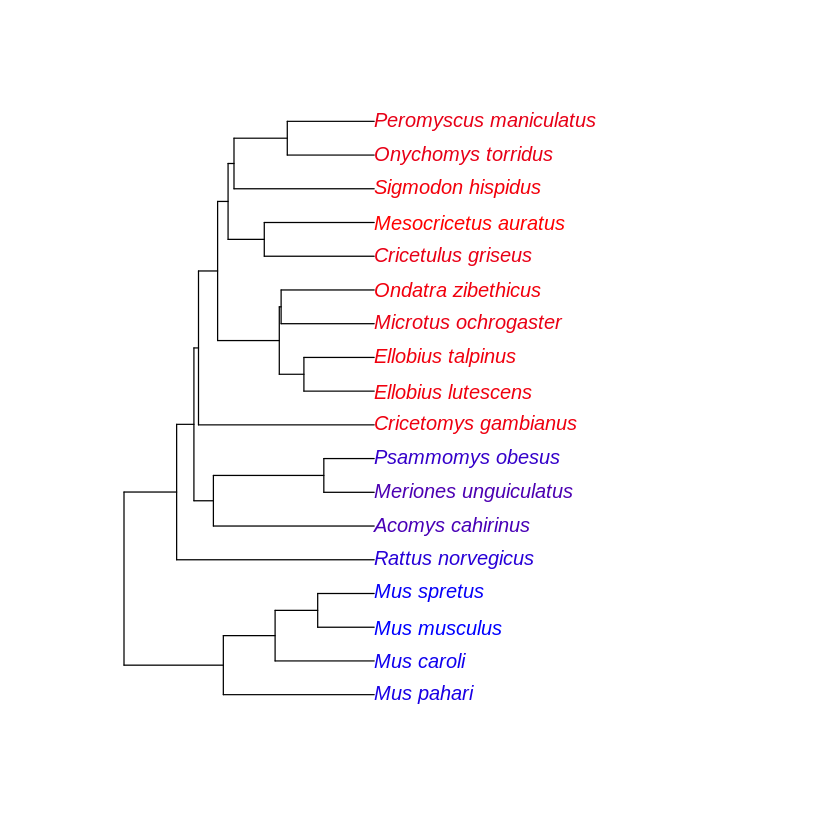

In [21]:
#### Color tip depending on molecular distance ######


#Note, scaling isn't necessary, but does improve visualiztion
#This scale between 0 and 1
speciesInfoF$MouseSplit_Cactus_Scale <- peakMeansV - min(peakMeansV[liverClTree$tip.label]);
speciesInfoF$MouseSplit_Cactus_Scale <- speciesInfoF$MouseSplit_Cactus * (1/(max(speciesInfoF[liverClTree$tip.label,"MouseSplit_Cactus"])));

#### Add tip label depending on whether species is mus ######

tipColorsM <- colorRamp(c("blue","red"),space= "rgb")(speciesInfoF[liverClTree$tip.label,"MouseSplit_Cactus_Scale"])
tipColorsV <- apply(tipColorsM,1,function(x) rgb(x[1],x[2],x[3],maxColorValue=255));

plot(liverClTree, show.tip.label = TRUE,
     edge.color = "black", edge.width = 1, edge.lty = 1,
     tip.color = tipColorsV)


In [ ]:
##########################################
##### Get regions that are different between Mus genus and other rodents #####
##########################################
#Example of zoonomia tree

This section describes how to use a basic t-test to identify differences in open chromatin across species. In this example, we will identify peaks that are different between species in the Mus genus vs. other rodents.

In [22]:
### Set the species of interest ####
foregroundSpeciesV <- speciesInfoF[which(speciesInfoF$isMus == "yes"),"Species"]
backgroundSpeciesV <- setdiff(keepSpeciesV,foregroundSpeciesV);

foregroundSpeciesV
backgroundSpeciesV

[1] "Mus_musculus" "Mus_caroli"   "Mus_pahari"   "Mus_spretus"

[1] "Acomys_cahirinus"       "Cricetomys_gambianus"   "Cricetulus_griseus"    
 [4] "Ellobius_lutescens"     "Ellobius_talpinus"      "Meriones_unguiculatus" 
 [7] "Mesocricetus_auratus"   "Microtus_ochrogaster"   "Ondatra_zibethicus"    
[10] "Onychomys_torridus"     "Peromyscus_maniculatus" "Psammomys_obesus"      
[13] "Rattus_norvegicus"      "Sigmodon_hispidus"

In [23]:
#This will take a few minutes
diffPvaluesV <- rep(NA,length(peakInfoF$id)); #Create an empty vector to store the p-values per open chromatin region in
names(diffPvaluesV) <- peakInfoF$id; #Name that vector with the peak names
diffMeansV <- diffPvaluesV #Create a new vector, also empty, to store the differences across species

for(curPeak in peakInfoF$id) { #Loop through each of the peaks
  curForegroundValuesV <- peakPredM[curPeak,foregroundSpeciesV]; #For that peak get the foreground predicitons
  curBackgroundValuesV <- peakPredM[curPeak,backgroundSpeciesV]; #For that peak get the background predicitons
  if(length(which(!is.na(curForegroundValuesV))) > 1 && length(which(!is.na(curBackgroundValuesV))) > 1) { #Ensure there are enough values
    if(sd(curForegroundValuesV,na.rm=T) > 0 && sd(curBackgroundValuesV,na.rm=T) > 0) { #Ensure that standard deviation greater than 0
      curTtest <- t.test(x=curForegroundValuesV,y=curBackgroundValuesV);
      diffPvaluesV[curPeak] <- curTtest$p.value
      diffMeansV[curPeak] <- mean(peakPredM[curPeak,foregroundSpeciesV],na.rm=T) - mean(peakPredM[curPeak,backgroundSpeciesV],na.rm=T);
    }
  }

}

In [24]:
#Create a dataframe based on the results
#The function p.adjust will correct the p-value for multiple hypothesis testing
diffResultsF <- data.frame(id=peakInfoF$id, meanDiff=diffMeansV, pvalue=diffPvaluesV, padj = p.adjust(diffPvaluesV))
diffResultsF[1:10,]

,id,meanDiff,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
peak1_mo,peak1_mo,0.497535318,6.204670e-03,1.0000000
peak3_mo,peak3_mo,0.243371942,1.563832e-02,1.0000000
peak4_mo,peak4_mo,-0.099439625,7.351972e-02,1.0000000
peak6_mo,peak6_mo,0.395848750,4.970940e-05,0.5766290
peak9_mo,peak9_mo,0.104603625,2.757265e-04,1.0000000
peak10_mo,peak10_mo,0.541583881,3.566526e-05,0.4164276
peak16_mo,peak16_mo,0.224008143,1.068069e-01,1.0000000
peak21_mo,peak21_mo,0.004233000,9.390406e-01,1.0000000
peak22_mo,peak22_mo,0.220126607,7.511855e-03,1.0000000


In [25]:
#Sort the results based on the adjusted p-value to view the top hits
diffResultsSortF <- diffResultsF[order(diffResultsF$padj),]
diffResultsSortF[1:10,]

,id,meanDiff,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>
peak18864_mo,peak18864_mo,0.8628422,5.387125e-20,6.863198e-16
peak5983_mo,peak5983_mo,0.8576679,7.013157e-17,8.934061e-13
peak10512_mo,peak10512_mo,0.6111922,2.046824e-15,2.607245e-11
peak18803_mo,peak18803_mo,0.8124720,6.414137e-15,8.169687e-11
peak4946_mo,peak4946_mo,0.6509059,3.838694e-14,4.888961e-10
peak3426_mo,peak3426_mo,0.7602988,5.056694e-14,6.439700e-10
peak21279_mo,peak21279_mo,0.8885959,9.131670e-14,1.162827e-09
peak9743_mo,peak9743_mo,0.8455081,1.019468e-13,1.298088e-09
peak13419_mo,peak13419_mo,0.7441961,1.181709e-13,1.504551e-09


In [26]:
#For a given peak (peak18864_mo) print out the open chromatin predictions for foreground and background species

peakPredM["peak18864_mo",foregroundSpeciesV]
peakPredM["peak18864_mo",backgroundSpeciesV]

Mus_musculus   Mus_caroli   Mus_pahari  Mus_spretus 
    0.934882     0.928819     0.950852     0.943771

Acomys_cahirinus   Cricetomys_gambianus     Cricetulus_griseus 
             0.0950290              0.0557860              0.0727795 
    Ellobius_lutescens      Ellobius_talpinus  Meriones_unguiculatus 
             0.0799175              0.0811795              0.0788850 
  Mesocricetus_auratus   Microtus_ochrogaster     Ondatra_zibethicus 
             0.0370920              0.1288730              0.0417430 
    Onychomys_torridus Peromyscus_maniculatus       Psammomys_obesus 
             0.0907600              0.0278635              0.0281045 
     Rattus_norvegicus      Sigmodon_hispidus 
             0.2141720              0.0421590

In [27]:
#Get the coordinates from a specific peak of interest
peakInfoF["peak18864_mo",]

,chr,start,stop,id
,<chr>,<int>,<int>,<chr>
peak18864_mo,chr15,96163223,96163576,peak18864_mo


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 39 rows containing non-finite outside the scale range (`stat_bin()`).”


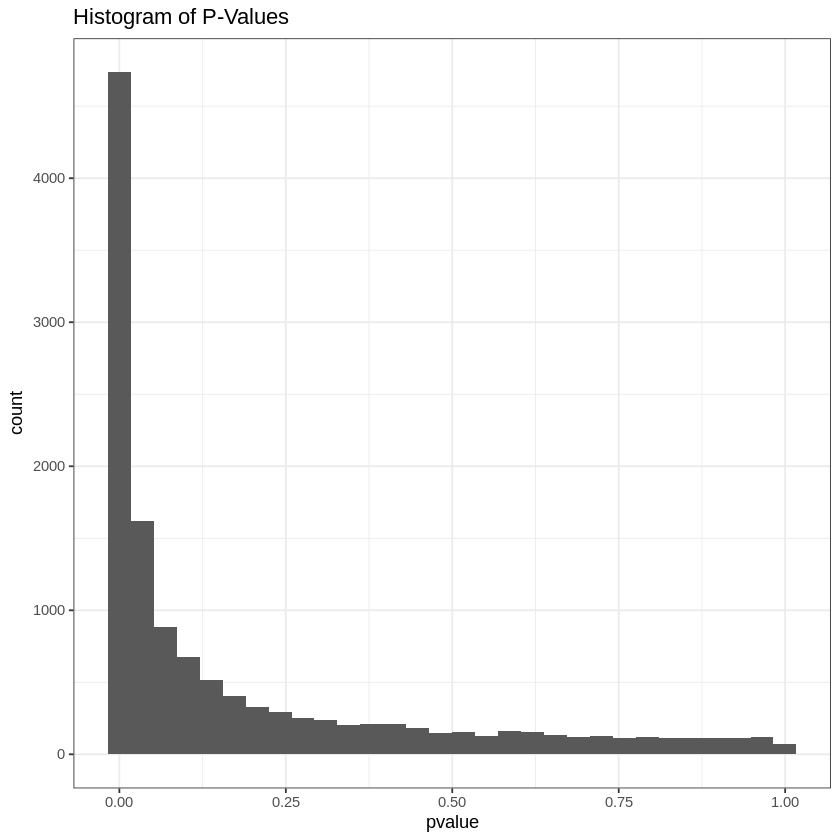

In [28]:
#Create a plot of the histogram of p-values
#If the data is random, then the distibution should be uniform
#However, if there are big trends, the data is shifted to the left
curP <- ggplot(diffResultsSortF, aes(x = pvalue)) +
  geom_histogram() + #This tells ggplot to create a histogram based on the x values
  ggtitle("Histogram of P-Values") +
  theme_bw();

print(curP);

In [ ]:
##########################################
##### Try to find associations Using Phylolm #####
##########################################

In [29]:
########### Read in the longevity phenotype ##################
#phenotypesF <- read.csv(file="https://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/project/Phenotypes_Zoonomia_3.csv",stringsAsFactors=F);

longevityF <- read.csv(file="https://www.andrew.cmu.edu/user/apfennin/2021_Fall_GEB/hw2/pantheriaLongevity.csv",stringsAsFactors=F)
longevityV <- longevityF$X17_MaxLongevity;
names(longevityV) <- gsub(" ","_",longevityF$Species)
longevityV[1:5];
longevityV[which(longevityV == -999)] <- NA;

speciesDetailedInfoF <-  speciesInfoF;
speciesDetailedInfoF$longevity <- longevityV[match(speciesDetailedInfoF$Species,names(longevityV))];

#longevityV
#pantheriaLongevity.csv






Canis_lupus       Ceratotherium_simum    Pontoporia_blainvillei 
                    354.0                     600.0                     192.0 
    Macrotus_californicus Rhinolophus_ferrumequinum 
                    124.8                     360.0

In [30]:
########## Loop through the peaks and calculate longevity relationship with phylolm ###############
#This could take a few minutes

testPeaksV <- rownames(peakPredM);

#loopPeaksV <- testPeaksV[1:1000];
loopPeaksV <- testPeaksV;

peakPhyloResultsF <- data.frame(peakId = loopPeaksV, pvalue=rep(NA,length(loopPeaksV)),correlation=rep(NA,length(loopPeaksV)),adjCorrelation=rep(NA,length(loopPeaksV)));
rownames(peakPhyloResultsF) <- peakPhyloResultsF$peakId

options(warn=-1)

for(curPeak in loopPeaksV) {
  speciesDetailedInfoTmpF <- speciesDetailedInfoF;
  speciesDetailedInfoTmpF$curPeak <- peakPredM[curPeak,];

  curLmFit = phylolm(curPeak~longevity,data=speciesDetailedInfoTmpF,phy=zoonomiaTree,model="BM");
  curLmFitSum <- summary(curLmFit)
  peakPhyloResultsF[curPeak,"pvalue"] <- curLmFitSum$coefficients["longevity","p.value"]
  peakPhyloResultsF[curPeak,"correlation"] <- curLmFitSum$r.squared
  peakPhyloResultsF[curPeak,"adjCorrelation"] <- curLmFitSum$adj.r.squared
}

options(warn=0)

peakPhyloResults2F <- peakPhyloResultsF[order(peakPhyloResultsF$pvalue,decreasing=F),]
peakPhyloResults2F[1:10,]

,peakId,pvalue,correlation,adjCorrelation
,<chr>,<dbl>,<dbl>,<dbl>
peak17641_mo,peak17641_mo,2.479105e-20,0.4552762,0.4514129
peak2608_mo,peak2608_mo,2.543632e-15,0.4842540,0.4788251
peak17640_mo,peak17640_mo,2.496286e-11,0.2716370,0.2664713
peak2592_mo,peak2592_mo,2.953187e-11,0.2783544,0.2730482
peak11495_mo,peak11495_mo,4.422389e-10,0.5909111,0.5816137
peak19639_mo,peak19639_mo,5.705708e-10,0.2829388,0.2767572
peak19643_mo,peak19643_mo,6.859991e-10,0.2433108,0.2377876
peak17902_mo,peak17902_mo,1.624256e-09,0.3369990,0.3295495
peak4653_mo,peak4653_mo,2.732340e-09,0.2373662,0.2315446


Warning message:
“Removed 160 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 160 rows containing missing values or values outside the scale range
(`geom_point()`).”


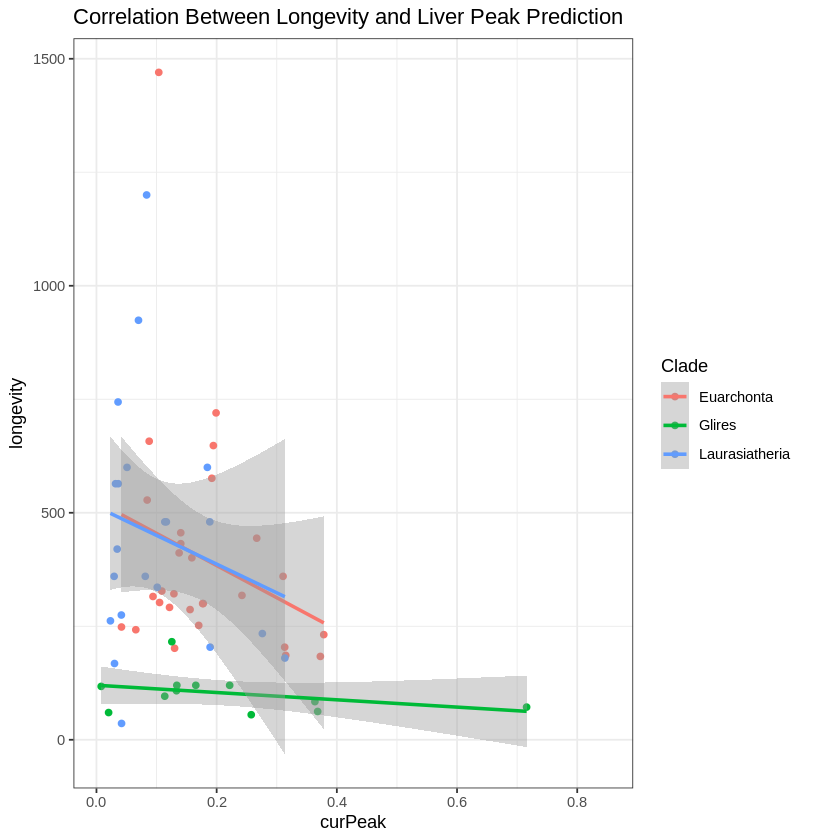

In [31]:
curPeak <- "peak339_mo";
speciesDetailedInfoTmpF <- speciesDetailedInfoF;
speciesDetailedInfoTmpF$curPeak <- peakPredM[curPeak,];

#Use ggplot to create a scatter plot
curP <- ggplot(speciesDetailedInfoTmpF, aes(x = curPeak , y = longevity,color=Clade)) + #Set the data variables to use
  geom_point() + #This specifies that you would like a scatter plot
  geom_smooth(method='lm', formula= y~x) + #This creates a trend line
  ggtitle("Correlation Between Longevity and Liver Peak Prediction") + #This creates a title for the plot
  theme_bw(); #This sets a basic theme for the plot style

print(curP); #Print the plot




`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


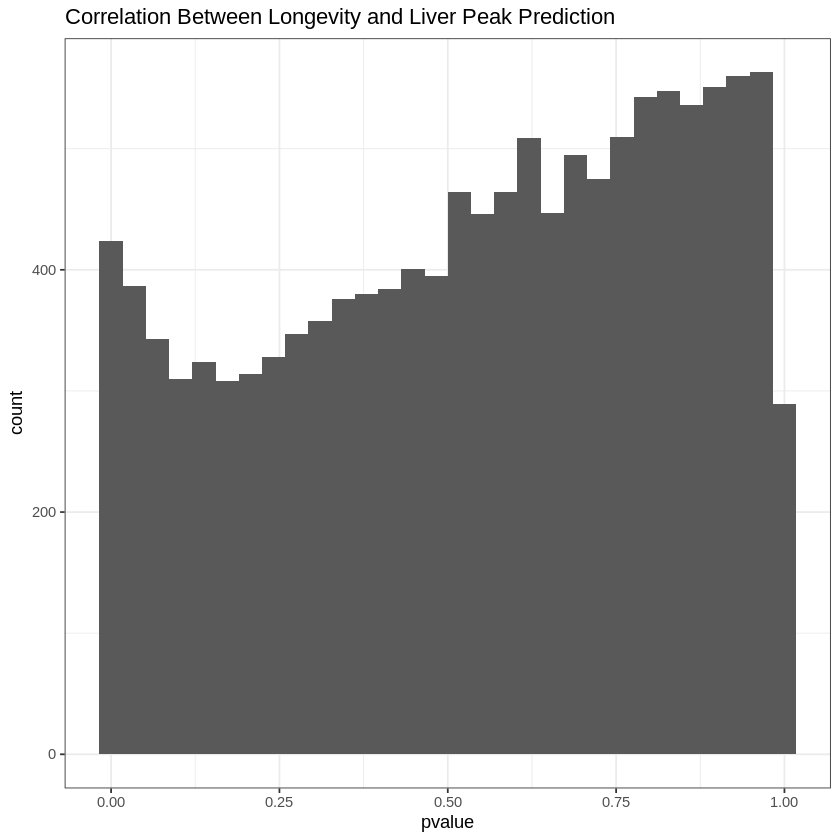

In [32]:
#Use to plot the histogram of p-values
curP <- ggplot(peakPhyloResults2F, aes(x = pvalue)) + #Set the data variables to use
  geom_histogram() + #This specifies that you would like a scatter plot
  #geom_smooth(method='lm', formula= y~x) + #This creates a trend line
  ggtitle("Correlation Between Longevity and Liver Peak Prediction") + #This creates a title for the plot
  theme_bw(); #This sets a basic theme for the plot style

print(curP); #Print the plot